In [1]:
%load_ext autoreload
%autoreload 2
from loguru import logger
import sys

### Check the result for each candidate

In [6]:
from evaluation_utils import ActivityEvaluator
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import nest_asyncio
nest_asyncio.apply()

In [7]:
folder = "results"
ground_truth_folder = "data"
llms = ["gpt-4o-mini", "gpt-4o", "Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct", "qwq-32b"]
llm_labels = [
    "GPT-4o-mini", "GPT-4o", "Llama3.1-8B", "Llama3.1-70B", "QwQ-32B"
]

dataset = "paged"
num_generations = range(1, 11)

In [8]:
evaluator = ActivityEvaluator("", dataset)

In [9]:
llm_results = {}
for llm in llms:
    results = {
        "con": [],
        "incon": []
    }
    folder_path = f"{folder}/{llm}"
    for num_generation in tqdm(num_generations):
        df = pd.read_csv(f"{folder_path}/{dataset}/results_{num_generation}.csv")[
            "0"
        ].tolist()
        evaluation_results = evaluator.evaluate_solutions(df, return_value="all")
        num_samples = len(evaluation_results["f1"])
        f1_con = np.mean(
            [
                evaluation_results["f1"][i]
                for i in range(num_samples)
                if evaluation_results["consistency"][i]
            ]
        )
        f1_incon = np.mean(
            [
                evaluation_results["f1"][i]
                for i in range(num_samples)
                if not evaluation_results["consistency"][i]
            ]
        )

        results["con"].append(f1_con)
        results["incon"].append(f1_incon)
    llm_results[llm] = results

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [10]:
num_generation = 10
abscon_result = {}
for llm in tqdm(llms):
    folder_path = f"{folder}/{llm}"
    df = pd.read_csv(f"{folder_path}/{dataset}/results_abscon_{num_generation}.csv")[
        "0"
    ].tolist()
    evaluation_results = evaluator.evaluate_solutions(df, return_value="avg")
    # print(len(evaluation_results["f1"]))
    results = {
        "abscon": [evaluation_results["f1"]]
    }

    abscon_result[llm] = results

  0%|          | 0/5 [00:00<?, ?it/s]

In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [12]:
## Plot the difference between consistent and non-consistent candidates
llm_results_categorization = {
    "abscon": [],
    "consistent": [],
    "inconsistent": []
}

for llm in llms:
    llm_results_categorization["abscon"].append(abscon_result[llm]["abscon"])
    llm_results_categorization["consistent"].append(llm_results[llm]["con"])
    llm_results_categorization["inconsistent"].append(llm_results[llm]["incon"])


In [13]:
abscon_result[llm]["abscon"]

[0.780258501218205]

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
plt.style.use(['science', "ieee"])


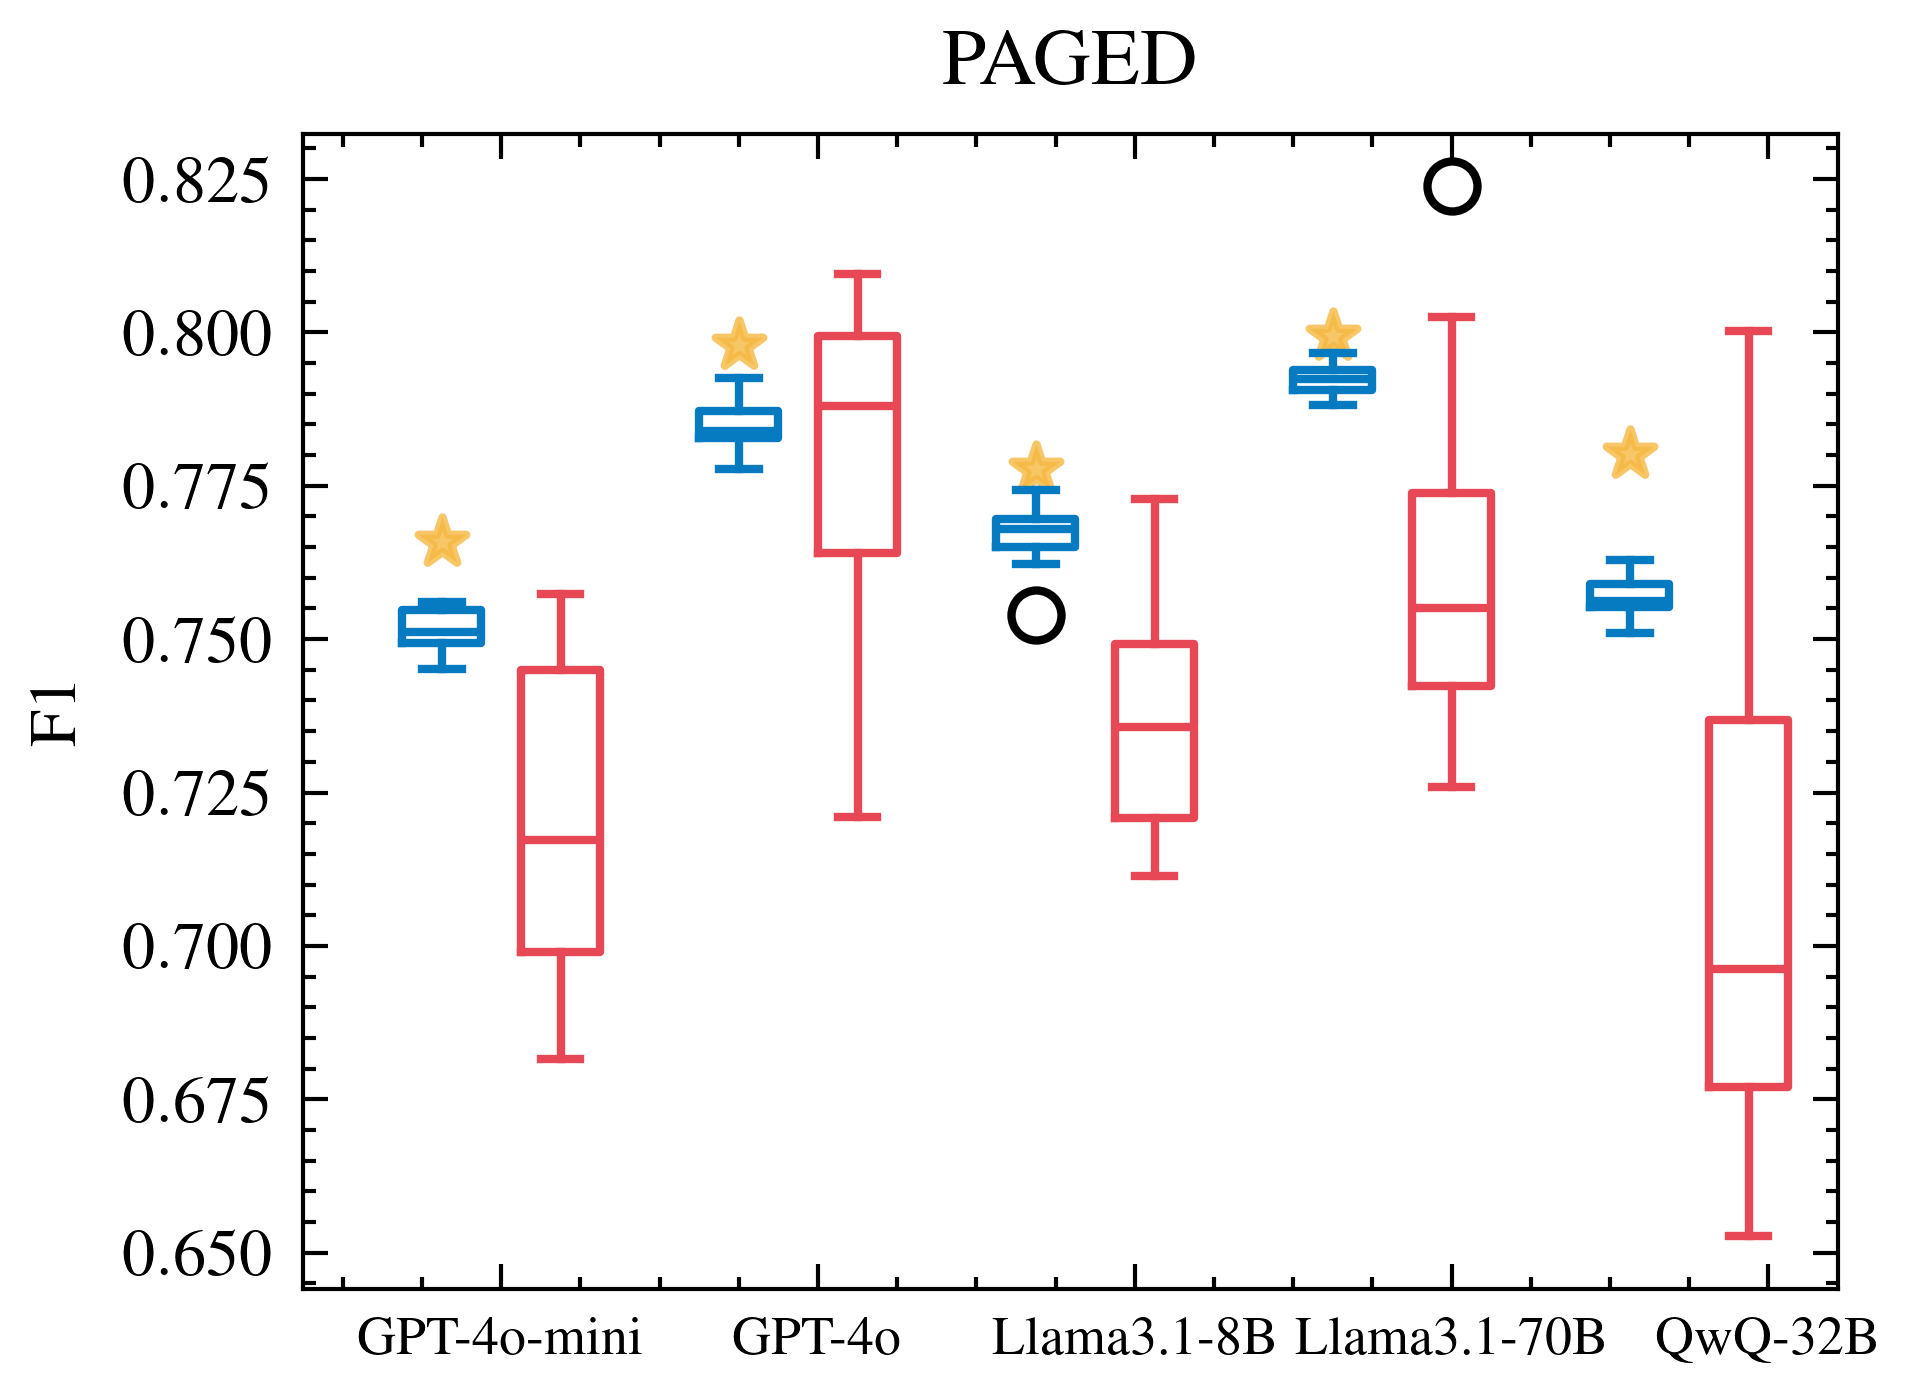

In [36]:
abscon_results = llm_results_categorization["abscon"]
# abscon_plot = plt.boxplot(abscon_results,
#                                positions=np.array(
#     np.arange(len(abscon_results)))*3.0-0.8,
#                                widths=0.8)

for i, abscon_result in enumerate(abscon_results):
    abscon_plot = plt.scatter(
        i * 3.0 - 0.6,
        abscon_results[i],
        alpha=0.8,
        label="AbsCon" if i == 0 else None,
        marker="*",
        color="#F5B841",
        # s=100,        # default is ~36, so this is much bigger
        # zorder=3,     # optional: draws stars on top of the box lines
    )
consistent_results = llm_results_categorization["consistent"]
consistent_plot = plt.boxplot(
    consistent_results,
    positions=np.array(np.arange(len(consistent_results))) * 3.0 - 0.6,
    widths=0.8,
)

inconsistent_results = llm_results_categorization["inconsistent"]
inconsistent_plot = plt.boxplot(
    inconsistent_results,
    positions=np.array(np.arange(len(inconsistent_results))) * 3.0 + 0.6,
    widths=0.8,
)


def define_box_properties(plot_name, color_code, label):
    for k, v in plot_name.items():
        plt.setp(plot_name.get(k), color=color_code)

    # use plot function to draw a small line to name the legend.
    plt.plot([], c=color_code, label=label)
    # plt.legend()
# plt.legend()

# setting colors for each groups
# define_box_properties(abscon_plot, '#F5B841', 'AbsCon')
define_box_properties(consistent_plot, "#067BC2", "Consistent")
define_box_properties(inconsistent_plot, "#E84855", "Inconsistent")

plt.xticks(np.arange(0, len(llm_labels) * 3.2, 3.2), llm_labels, fontsize=6.5)
plt.xlim(-2, len(llm_labels) * 2.7)
# plt.xticks(np.arange(len(llm_labels)) * 3.0, llm_labels,
#            rotation=5, ha="right", rotation_mode="anchor")

plt.ylabel("F1")
plt.title("PAGED")
plt.savefig(f"PAGED.pdf", dpi=300)
plt.show()

In [38]:
print(llm_labels)

['GPT-4o-mini', 'GPT-4o', 'Llama3.1-8B', 'Llama3.1-70B', 'QwQ-32B']


In [42]:
from cliffs_delta import cliffs_delta, lookup_size
from scipy.stats import ranksums

In [43]:
statistical_test_results = []
for consistent_result, inconsistent_result in zip(consistent_results, inconsistent_results):
    statistical_test_results.append(ranksums(consistent_result, inconsistent_result, alternative="greater"))


In [44]:
statistical_test_results

[RanksumsResult(statistic=2.7969371002682815, pvalue=0.002579478785360654),
 RanksumsResult(statistic=-0.07559289460184544, pvalue=0.5301285052114634),
 RanksumsResult(statistic=3.0993086786756634, pvalue=0.0009698640564515203),
 RanksumsResult(statistic=2.2677868380553634, pvalue=0.011671101006445408),
 RanksumsResult(statistic=2.2677868380553634, pvalue=0.011671101006445408)]

In [45]:
dull = {'small': 0.147, 'medium': 0.33, 'large': 0.474} # effect sizes from (Hess and Kromrey, 2004)

In [46]:
cliffs_values = []
for consistent_result, inconsistent_result in zip(consistent_results, inconsistent_results):
    cliffs_values.append(cliffs_delta(consistent_result, inconsistent_result)[0])
mean_cliff = np.mean(cliffs_values)

In [47]:
cliffs_values

[0.74, -0.02, 0.82, 0.6, 0.6]

In [ ]:
mean_cliff

In [ ]:
lookup_size(mean_cliff, dull)